In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from itertools import product

# ============================================================
# 설정값
# ============================================================
DATA_DIR     = "./cifar-10-batches-py"   # CIFAR-10 경로 수정
TRAIN_SUBSET = 5000                      # 속도를 위해 5,000장만 사용
LEARNING_RATES  = [1e-4, 5e-4, 1e-3, 5e-3]
REG_STRENGTHS   = [1e-4, 1e-3, 1e-2]
NUM_EPOCHS   = 200
BATCH_SIZE   = 256

In [2]:
# ============================================================
# 1. 데이터 로드
# ============================================================
def load_cifar10_batch(filepath):
    with open(filepath, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    images = batch[b"data"].astype(np.float32)
    labels = np.array(batch[b"labels"], dtype=np.int32)
    return images, labels

def load_cifar10(data_dir):
    X_list, y_list = [], []
    for i in range(1, 6):
        X_b, y_b = load_cifar10_batch(os.path.join(data_dir, f"data_batch_{i}"))
        X_list.append(X_b)
        y_list.append(y_b)
    X_train = np.concatenate(X_list, axis=0)
    y_train = np.concatenate(y_list, axis=0)
    X_test, y_test = load_cifar10_batch(os.path.join(data_dir, "test_batch"))
    return X_train, y_train, X_test, y_test

# ============================================================
# 2. 전처리 (zero-center + 바이어스 트릭)
# ============================================================
def preprocess(X_train_raw, y_train_raw, X_test_raw, subset=None):
    # 서브셋 추출
    if subset is not None:
        idx = np.random.choice(len(X_train_raw), subset, replace=False)
        X_train_raw = X_train_raw[idx]
        y_train_raw = y_train_raw[idx]

    # 훈련셋 기준 평균 빼기 (zero-centering)
    mean_img = X_train_raw.mean(axis=0)
    X_train  = X_train_raw - mean_img
    X_test   = X_test_raw  - mean_img

    # 바이어스 트릭: f(x,W) = Wx (b를 W에 흡수)
    X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
    X_test  = np.hstack([X_test,  np.ones((X_test.shape[0],  1))])

    return X_train, y_train_raw, X_test

# ============================================================
# 3. SVM Hinge Loss
# ============================================================
def svm_loss(W, X, y, reg):
    """
    L_i = Σ_{j≠y_i} max(0, s_j - s_{y_i} + 1)
    L   = (1/N) Σ L_i  +  reg * ||W||²
    """
    N = X.shape[0]
    scores = X @ W.T                                           # (N, C)
    correct_scores = scores[np.arange(N), y].reshape(-1, 1)   # 정답 클래스 점수
    margins = np.maximum(0, scores - correct_scores + 1)      # hinge
    margins[np.arange(N), y] = 0                              # 정답 클래스 제외

    loss = margins.sum() / N + reg * np.sum(W * W)

    # 그래디언트
    mask = (margins > 0).astype(float)
    mask[np.arange(N), y] = -mask.sum(axis=1)
    dW = (mask.T @ X) / N + 2 * reg * W

    return loss, dW

# ============================================================
# 4. 선형 분류기
# ============================================================
class LinearClassifier:
    def __init__(self, num_classes=10):
        self.W = None
        self.C = num_classes

    def train(self, X, y, lr=1e-3, reg=1e-4, num_epochs=200, batch_size=256):
        N, D = X.shape
        if self.W is None:
            self.W = np.random.randn(self.C, D) * 0.001   # 가중치 초기화

        steps = max(N // batch_size, 1)
        for _ in range(num_epochs):
            perm = np.random.permutation(N)
            X_s, y_s = X[perm], y[perm]
            for step in range(steps):
                s, e = step * batch_size, min((step + 1) * batch_size, N)
                loss, dW = svm_loss(self.W, X_s[s:e], y_s[s:e], reg)
                self.W -= lr * dW                          # SGD 업데이트

    def predict(self, X):
        return (X @ self.W.T).argmax(axis=1)              # 점수 최대 클래스 반환

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

In [9]:
# ============================================================
# 5. 5-Fold Cross-Validation
# ============================================================
def five_fold_cross_validation(X, y, learning_rates, reg_strengths,
                                num_epochs=200, batch_size=256):
    N, K = X.shape[0], 5
    fold_size = N // K
    results = {}   # {(lr, reg): [acc_fold1, ..., acc_fold5]}

    total = len(learning_rates) * len(reg_strengths)
    print(f"\n{'='*60}")
    print(f"  5-Fold Cross-Validation")
    print(f"  Samples: {N}  |  Fold size: {fold_size}  |  Combos: {total}")
    print(f"{'='*60}")

    for idx, (lr, reg) in enumerate(product(learning_rates, reg_strengths), 1):
        fold_accs = []
        for fold in range(K):
            vs, ve = fold * fold_size, (fold + 1) * fold_size
            X_val, y_val = X[vs:ve], y[vs:ve]
            X_tr  = np.concatenate([X[:vs], X[ve:]], axis=0)
            y_tr  = np.concatenate([y[:vs], y[ve:]], axis=0)

            clf = LinearClassifier()
            clf.train(X_tr, y_tr, lr=lr, reg=reg,
                      num_epochs=num_epochs, batch_size=batch_size)
            fold_accs.append(clf.accuracy(X_val, y_val))

        results[(lr, reg)] = fold_accs
        mean_acc = np.mean(fold_accs)
        print(f"  [{idx:2d}/{total}] Learning Rate={lr:.0e}  Regularization={reg:.0e}"
              f"  →  mean_acc={mean_acc:.4f}")

    best_key = max(results, key=lambda k: np.mean(results[k]))
    best_lr, best_reg = best_key
    print(f"\n  Best → Learning Rate={best_lr:.0e}  Regularization={best_reg:.0e}"
          f"  mean_acc={np.mean(results[best_key]):.4f}")
    print(f"{'='*60}\n")
    return results, best_lr, best_reg

# ============================================================
# 6. 5-Fold CV 그래프
# ============================================================
def plot_cv_results(results, learning_rates, reg_strengths):
    """
    X축: Learning Rate 값
    Y축: Mean Cross-Validation Accuracy
    reg_strength마다 별도 선 표시
    """
    plt.figure(figsize=(8, 5))
    for reg in reg_strengths:
        mean_accs = [np.mean(results[(lr, reg)]) for lr in learning_rates]
        std_accs  = [np.std(results[(lr, reg)])  for lr in learning_rates]
        plt.errorbar(range(len(learning_rates)), mean_accs,
                     yerr=std_accs, marker="o",
                     label=f"reg={reg:.0e}", capsize=4)

    plt.xticks(range(len(learning_rates)),
               [f"{lr:.0e}" for lr in learning_rates])
    plt.xlabel("Learning Rate")
    plt.ylabel("Mean Cross-Validation Accuracy")
    plt.title("5-Fold Cross-Validation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("cv_results.png", dpi=150, bbox_inches="tight")
    plt.show()

# ============================================================
# 7. 평가지표 (Accuracy / Precision / Recall / F1)
# ============================================================
def evaluate(clf, X, y, num_classes=10):
    preds = clf.predict(X)
    acc   = np.mean(preds == y)

    precision_list, recall_list, f1_list = [], [], []
    for c in range(num_classes):
        tp = np.sum((preds == c) & (y == c))
        fp = np.sum((preds == c) & (y != c))
        fn = np.sum((preds != c) & (y == c))
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        precision_list.append(p)
        recall_list.append(r)
        f1_list.append(f1)

    # Macro average (클래스별 평균)
    macro_p  = np.mean(precision_list)
    macro_r  = np.mean(recall_list)
    macro_f1 = np.mean(f1_list)
    return acc, macro_p, macro_r, macro_f1, precision_list, recall_list, f1_list

In [7]:
# ============================================================
# 데이터 로드 및 전처리 실행
# ============================================================
np.random.seed(1)

# 데이터 로드
print("Loading CIFAR-10...")
X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_cifar10(DATA_DIR)

# 전처리
print(f"Preprocessing  (subset={TRAIN_SUBSET})...")
X_train, y_train, X_test = preprocess(
    X_train_raw, y_train_raw, X_test_raw, subset=TRAIN_SUBSET)

Loading CIFAR-10...
Preprocessing  (subset=5000)...


In [10]:
# ============================================================
# 5-Fold CV 실행
# ============================================================
cv_results, best_lr, best_reg = five_fold_cross_validation(
    X_train, y_train,
    LEARNING_RATES, REG_STRENGTHS,
    num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE)


  5-Fold Cross-Validation
  Samples: 5000  |  Fold size: 1000  |  Combos: 12
  [ 1/12] Learning Rate=1e-04  Regularization=1e-04  →  mean_acc=0.2590
  [ 2/12] Learning Rate=1e-04  Regularization=1e-03  →  mean_acc=0.2576
  [ 3/12] Learning Rate=1e-04  Regularization=1e-02  →  mean_acc=0.2664
  [ 4/12] Learning Rate=5e-04  Regularization=1e-04  →  mean_acc=0.2688
  [ 5/12] Learning Rate=5e-04  Regularization=1e-03  →  mean_acc=0.2634
  [ 6/12] Learning Rate=5e-04  Regularization=1e-02  →  mean_acc=0.2628
  [ 7/12] Learning Rate=1e-03  Regularization=1e-04  →  mean_acc=0.2634
  [ 8/12] Learning Rate=1e-03  Regularization=1e-03  →  mean_acc=0.2668
  [ 9/12] Learning Rate=1e-03  Regularization=1e-02  →  mean_acc=0.2654
  [10/12] Learning Rate=5e-03  Regularization=1e-04  →  mean_acc=0.2700
  [11/12] Learning Rate=5e-03  Regularization=1e-03  →  mean_acc=0.2648
  [12/12] Learning Rate=5e-03  Regularization=1e-02  →  mean_acc=0.2446

  Best → Learning Rate=5e-03  Regularization=1e-04  mean_

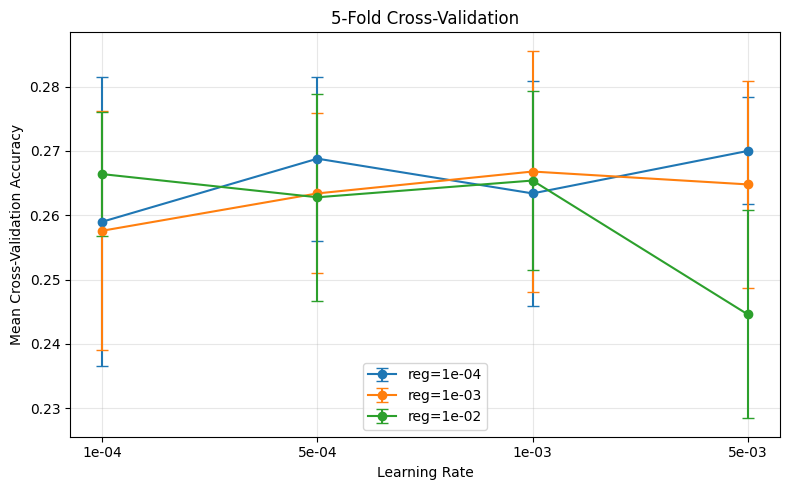

In [11]:
# 그래프 그리기
plot_cv_results(cv_results, LEARNING_RATES, REG_STRENGTHS)

In [12]:
# ============================================================
# 최종 모델 학습 및 평가
# ============================================================
print(f"Training final model  (Learning Rate={best_lr:.0e}, Regularization={best_reg:.0e})...")
final_clf = LinearClassifier()
final_clf.train(X_train, y_train,
                lr=best_lr, reg=best_reg,
                num_epochs=NUM_EPOCHS * 2,
                batch_size=BATCH_SIZE)

# 평가 출력
class_names = ["0","1","2","3","4",
               "5","6","7","8","9"]

acc, prec, rec, f1, prec_l, rec_l, f1_l = evaluate(final_clf, X_test, y_test_raw)

print("\n" + "="*50)
print("  Evaluation on Test Set")
print("="*50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}  (macro avg)")
print(f"  Recall    : {rec:.4f}  (macro avg)")
print(f"  F1-Score  : {f1:.4f}  (macro avg)")
print("-"*50)
print(f"  {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*50)
for i, name in enumerate(class_names):
    print(f"  {name:<12} {prec_l[i]:>10.4f}"
          f" {rec_l[i]:>10.4f}"
          f" {f1_l[i]:>10.4f}")


Training final model  (Learning Rate=5e-03, Regularization=1e-04)...

  Evaluation on Test Set
  Accuracy  : 0.2722
  Precision : 0.2735  (macro avg)
  Recall    : 0.2722  (macro avg)
  F1-Score  : 0.2710  (macro avg)
--------------------------------------------------
  Class         Precision     Recall         F1
--------------------------------------------------
  0                0.2735     0.2620     0.2676
  1                0.3293     0.2970     0.3123
  2                0.2068     0.2320     0.2187
  3                0.1898     0.1930     0.1914
  4                0.2500     0.3120     0.2776
  5                0.2161     0.2280     0.2219
  6                0.2768     0.2250     0.2482
  7                0.2994     0.2620     0.2795
  8                0.3776     0.4660     0.4172
  9                0.3157     0.2450     0.2759
